# Image processing notebook: From overlap corrected to transmission 

### 00 - exp 1XX acquisition 00

##  Initial settings

### Import libraries
Import all the required libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
%matplotlib inline

### Select directories
Select the source directory. This directory is where the images **after** the overlap correction were saved.
Select the destination directory. Here is where the transmission images are going to be saved.

In [2]:
# %load select_directory('src_dir')
src_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\01_Overlap_corrected\exp103"

In [3]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp103"

### Check folders to process

In [4]:
stack_dict = prep_stack_dict(src_dir)
for key in stack_dict.keys():
    print(key)

000_ob_00
000_temp_00_m23_ob
001_ref_00
001_temp_00_m23_batch01
002_temp_00_m23_batch02
003_temp_00_m23_batch03
004_temp_01_p40_ob
005_temp_01_p40_batch01
006_temp_01_p40_batch02
007_temp_01_p40_batch03
008_temp_02_p20_ob
009_temp_02_p20_batch01


In [5]:
proc_folder1 = [key for key in stack_dict.keys() if 'batch01' in key]
proc_folder2 = [key for key in stack_dict.keys() if 'batch02' in key]
proc_folder3 = [key for key in stack_dict.keys() if 'batch03' in key]
ref_folder = ['001_ref_00']

**This experiment does not require slicing**

**Slicing the folders because the memory space does not allow to work with the full batch**

## Process the reference folder (if not done before)
Or in case it is not previously saved.

In case the parameters and ref_dict are stored in the global variables, you can load them with : `%store -r "name given"`

It is **important** to not process the images fully before having played with them to find the right parameters (there is a notebook called playgound todo this)

In [6]:
#%store -r exp_param
#ref_dir =  r"J:\700 Campaigns - internal\2021\PSI21_10NI_updated_framework\02_Transmission_results\exp102"
#ref_dict = read_saved_dict (ref_dir, proc_folder = ['001_ref_00'])

### Continue here if ref images are not done
if the ref images were done (with the same processing intended) then continue to section 3

In [7]:
ref_param = {}
nca_ref = [388, 10, 59, 488]

add_to_dict(ref_param, ['threshold', 'nca', 'ws_filter_size'], [0, nca_ref, 3])

In [8]:
ref_seq =  [stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict]

In [9]:
proc_folder = ref_folder
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_ref.fits')
add_to_dict(ref_param,['BB_mask'], [BB_mask])

ref_dict = full_processing (src_dir, dst_dir, proc_folder = ref_folder, sequence = ref_seq, 
                 proc_parameters = ref_param, img_name = 'intensity', save = True)

Reading Images: 100%|████████████████████████████| 3/3 [00:43<00:00, 14.50s/it]


Experiment 001_ref_00 in process...


Processing SBKG Correction: 100%|████████████████| 1/1 [00:40<00:00, 40.36s/it]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.33s/it]


Total time: 1018s


## Gettinging an NCA

In [11]:
test_folder01 = ['005_temp_01_p40_batch01']
test_folder02 = ['006_temp_01_p40_batch02']
test_folder03 = ['007_temp_01_p40_batch03']

img_dict01, _ = testing_mode_step (src_dir, proc_folder = test_folder01, keep_acq_numb = 1)
img_dict02, _ = testing_mode_step (src_dir, proc_folder = test_folder02, keep_acq_numb = 1)
img_dict03, _ = testing_mode_step (src_dir, proc_folder = test_folder03, keep_acq_numb = 1)

Reading Images: 100%|████████████████████████████| 3/3 [00:01<00:00,  1.50it/s]


In [12]:
img_batch01 = avg_frames_dict (img_dict01[test_folder01[0]], output_type = 'img')
img_batch02 = avg_frames_dict (img_dict02[test_folder02[0]], output_type = 'img')
img_batch03 = avg_frames_dict (img_dict03[test_folder03[0]], output_type = 'img')

In [13]:
# %load select_rois(img_batch01, list_rois = ['nca_01'])
nca_01 = [388, 10, 59, 488]

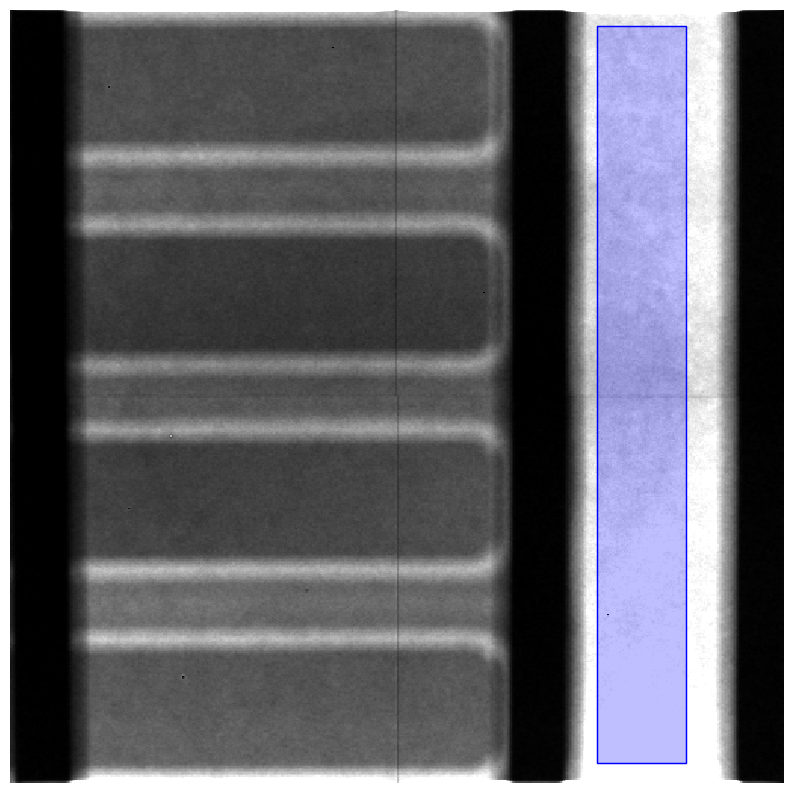

In [14]:
show_img(img_batch01[0], dr = [(nca_01, 'blue')], cmap='gray')

In [15]:
# %load select_rois(img_batch02, list_rois = ['nca_02'])
nca_02 = [390, 10, 59, 488]

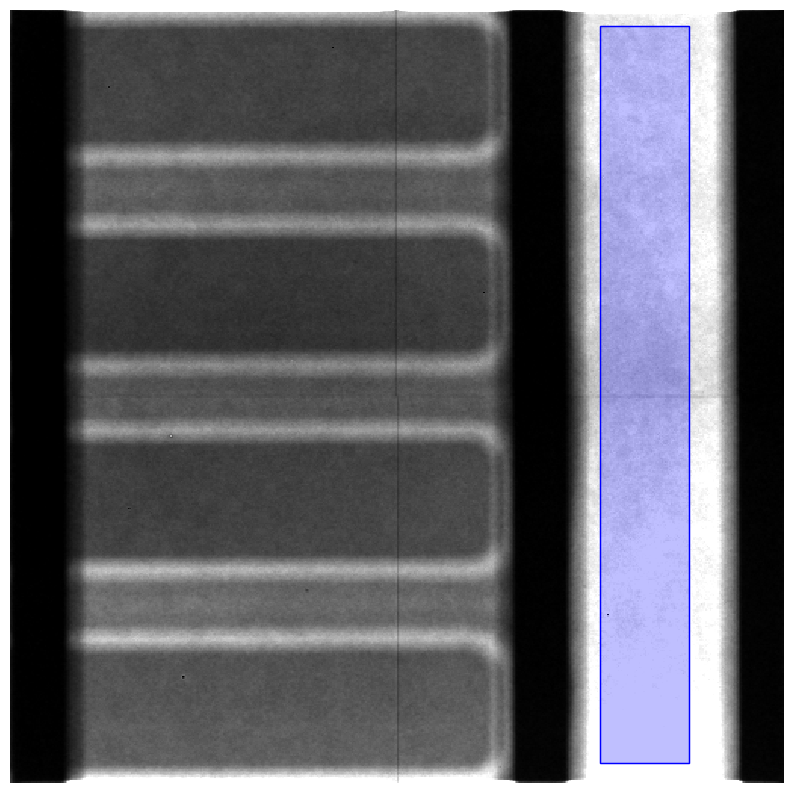

In [16]:
show_img(img_batch02[0], dr = [(nca_02, 'blue')], cmap='gray')

In [17]:
# %load select_rois(img_batch03, list_rois = ['nca_03'])
nca_03 = [390, 10, 59, 488]

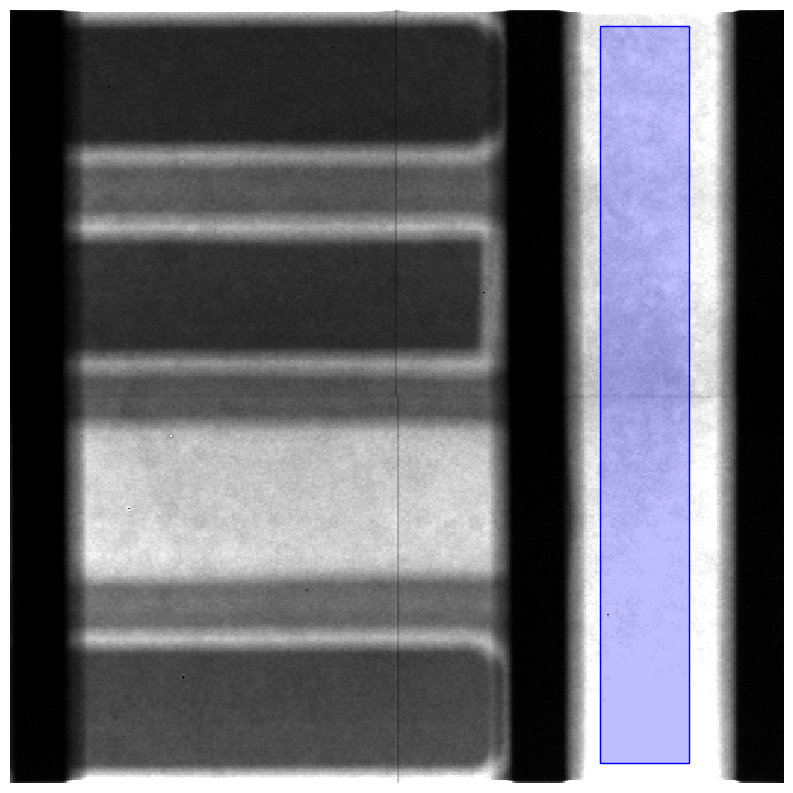

In [18]:
show_img(img_batch03[0], dr = [(nca_03, 'blue')], cmap='gray')

## Base parameters and Sequence

In [19]:
exp_param = {}

add_to_dict(exp_param, ['threshold', 'use_ref', 'ref_dict', 'ws_filter_size'], [0, True, ref_dict, 3])

In [20]:
exp_seq =  [stack_averaging,
            scrubbing_correction_dict,
            ws_filter,
            outlier_removal,
            SBKG_correction_dict,
            intensity_correction_dict,
            referencing_dict]

## Exp103 Processing

### Processing Batch 01

In [21]:
proc_folder = proc_folder1
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch01.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_01])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 6/6 [00:42<00:00,  7.07s/it]


Experiment 001_temp_00_m23_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.26it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.23s/it]


...

Experiment 009_temp_02_p20_batch01 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.11it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.92s/it]


Total time: 1243s


### Processing Batch 02

In [22]:
proc_folder = proc_folder2
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch02.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_02])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 5/5 [00:41<00:00,  8.32s/it]


Experiment 002_temp_00_m23_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  3.95it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.42s/it]


Experiment 006_temp_01_p40_batch02 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.12it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.49s/it]


Total time: 876s


### Processing Batch 03

In [23]:
proc_folder = proc_folder3
BB_mask = get_img(os.path.dirname(src_dir) + '/mask_batch03.fits')
add_to_dict(exp_param,['BB_mask', 'nca'], [BB_mask, nca_03])

exp_dict = full_processing (src_dir, dst_dir, proc_folder = proc_folder, sequence = exp_seq, 
                 proc_parameters = exp_param, img_name = 'transmission', save = True)

Reading Images: 100%|████████████████████████████| 5/5 [00:36<00:00,  7.27s/it]


Experiment 003_temp_00_m23_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.27it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.49s/it]


Experiment 007_temp_01_p40_batch03 in process...


Processing Referencing Correction: 100%|█████████| 1/1 [00:00<00:00,  4.30it/s]


Saving images as a single acquisition


Writing Images: 100%|████████████████████████████| 1/1 [00:21<00:00, 21.44s/it]


Total time: 882s
